In [1]:
!pip install pubchempy tensorflow scikit-learn pandas openpyxl rdkit-pypi


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [2]:
import os
import pandas as pd
import numpy as np
from tqdm import tqdm


In [3]:
# ✅ Update the path to your CSV file
DATA_PATH = '/Users/swara/Desktop/ey/EY_Techathon/Datasets/Drug Discovery and Repurposing Tool.csv'

# Check if the file exists
if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(f"Dataset not found at {DATA_PATH}. Update DATA_PATH to your CSV file.")

# Load the CSV file
df = pd.read_csv(DATA_PATH)
print('✅ Loaded dataset successfully!')
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

✅ Loaded dataset successfully!
Shape: (100000, 3)
Columns: ['Drug', 'Repurposed_Use', 'Confidence_Level']


In [4]:
# ============================================================
# 🧬 Cell 3: Fetch Unique Drug Names → SMILES (PubChem)
# ============================================================
try:
    import pubchempy as pcp
    PUBCHEM_AVAILABLE = True
except Exception:
    PUBCHEM_AVAILABLE = False
    print("⚠️ PubChemPy not available; ensure internet access for SMILES retrieval.")

def name_to_smiles_pubchem(drug_name):
    """Fetch canonical SMILES for a given drug name via PubChemPy."""
    if not PUBCHEM_AVAILABLE or not isinstance(drug_name, str):
        return None
    try:
        compounds = pcp.get_compounds(drug_name, 'name', as_objects=True)
        if compounds:
            return compounds[0].canonical_smiles
    except Exception:
        pass
    return None

# Get unique drug names
unique_drugs = df['Drug'].dropna().unique()
print(f"🔹 Found {len(unique_drugs)} unique drug names.")

# Generate SMILES only for unique drugs
smiles_map = {}
for drug in tqdm(unique_drugs, desc="🔍 Fetching unique SMILES"):
    smiles_map[drug] = name_to_smiles_pubchem(drug)

# Map SMILES back to full dataset
df['SMILES'] = df['Drug'].map(smiles_map)
print("✅ SMILES mapping complete.")
print(f"Resolved SMILES for {df['SMILES'].notna().sum()} drugs.")




🔹 Found 4 unique drug names.


🔍 Fetching unique SMILES:   0%|          | 0/4 [00:00<?, ?it/s]/var/folders/68/x__r7yk90713flk6dwyxljk80000gn/T/ipykernel_99201/4168247954.py:18: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compounds[0].canonical_smiles
🔍 Fetching unique SMILES:  25%|██▌       | 1/4 [00:01<00:05,  1.93s/it]/var/folders/68/x__r7yk90713flk6dwyxljk80000gn/T/ipykernel_99201/4168247954.py:18: PubChemPyDeprecationWarning: canonical_smiles is deprecated: Use connectivity_smiles instead
  return compounds[0].canonical_smiles
🔍 Fetching unique SMILES: 100%|██████████| 4/4 [00:05<00:00,  1.33s/it]

✅ SMILES mapping complete.
Resolved SMILES for 100000 drugs.


In [5]:
def clean_drug_name(drug_name):
    """Clean and standardize drug names before SMILES lookup."""
    if not isinstance(drug_name, str):
        return None
    
    # Clean and standardize
    cleaned = drug_name.strip().lower()
    
    # Handle common variations
    if cleaned.endswith('e'):  # e.g., 'azithromycine' -> 'azithromycin'
        cleaned = cleaned[:-1]
    
    return cleaned

# Update the name_to_smiles_pubchem function
def name_to_smiles_pubchem(drug_name):
    """Fetch canonical SMILES for a given drug name via PubChemPy with improved error handling."""
    if not PUBCHEM_AVAILABLE or not isinstance(drug_name, str):
        return None
    try:
        # Clean the drug name first
        cleaned_name = clean_drug_name(drug_name)
        if not cleaned_name:
            return None
            
        # Try multiple variations of the name
        variations = [
            cleaned_name,
            cleaned_name.replace(' ', ''),  # Remove spaces
            cleaned_name.replace('-', ''),  # Remove hyphens
        ]
        
        for variant in variations:
            try:
                compounds = pcp.get_compounds(variant, 'name', as_objects=True)
                if compounds:
                    smiles = compounds[0].canonical_smiles
                    # Verify SMILES is valid with RDKit
                    mol = Chem.MolFromSmiles(smiles)
                    if mol:
                        return Chem.MolToSmiles(mol, canonical=True)  # Return standardized form
                    continue
            except Exception:
                continue
        
        print(f"⚠️ Could not find valid SMILES for drug: {drug_name}")
        return None
        
    except Exception as e:
        print(f"⚠️ Error fetching SMILES for {drug_name}: {str(e)}")
        return None

In [6]:
df

,Drug,Repurposed_Use,Confidence_Level,SMILES
0,Atorvastatin,Cardioprotection,94,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
1,Metformin,Anti-inflammatory,94,CN(C)C(=N)N=C(N)N
2,Hydroxychloroquine,Cardioprotection,93,CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO
3,Atorvastatin,Antiviral,88,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
4,Atorvastatin,Antiviral,80,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
...,...,...,...,...
99995,Aspirin,Anti-inflammatory,85,CC(=O)OC1=CC=CC=C1C(=O)O
99996,Aspirin,Cancer treatment,88,CC(=O)OC1=CC=CC=C1C(=O)O
99997,Atorvastatin,Cancer treatment,95,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
99998,Hydroxychloroquine,Antiviral,90,CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO


In [7]:
from rdkit import Chem
from rdkit.Chem import AllChem


In [8]:
def smiles_to_fingerprint(smiles: str, radius: int = 2, nBits: int = 2048) -> np.ndarray:
    """Convert a SMILES string to a 2048-bit Morgan fingerprint."""
    if isinstance(smiles, str):
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
            return np.array(fp, dtype=np.int8)
    return None

# Compute fingerprints only for unique SMILES
fingerprint_map = {}
for drug, smi in tqdm(smiles_map.items(), desc="🧩 Computing unique fingerprints"):
    fingerprint_map[drug] = smiles_to_fingerprint(smi)

# Map fingerprints back to dataframe
fingerprints = []
valid_idx = []
for i, row in df.iterrows():
    drug = row['Drug']
    fp = fingerprint_map.get(drug)
    if fp is not None:
        fingerprints.append(fp)
        valid_idx.append(i)

fingerprints = np.array(fingerprints, dtype=np.float32)
print(f"✅ Fingerprints computed. Shape: {fingerprints.shape}")

df_valid = df.loc[valid_idx].reset_index(drop=True)
print('📦 Valid dataframe shape:', df_valid.shape)


🧩 Computing unique fingerprints: 100%|██████████| 4/4 [00:00<00:00, 525.21it/s]



✅ Fingerprints computed. Shape: (100000, 2048)
📦 Valid dataframe shape: (100000, 4)


In [9]:
df_valid

,Drug,Repurposed_Use,Confidence_Level,SMILES
0,Atorvastatin,Cardioprotection,94,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
1,Metformin,Anti-inflammatory,94,CN(C)C(=N)N=C(N)N
2,Hydroxychloroquine,Cardioprotection,93,CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO
3,Atorvastatin,Antiviral,88,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
4,Atorvastatin,Antiviral,80,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
...,...,...,...,...
99995,Aspirin,Anti-inflammatory,85,CC(=O)OC1=CC=CC=C1C(=O)O
99996,Aspirin,Cancer treatment,88,CC(=O)OC1=CC=CC=C1C(=O)O
99997,Atorvastatin,Cancer treatment,95,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...
99998,Hydroxychloroquine,Antiviral,90,CCN(CCCC(C)NC1=C2C=CC(=CC2=NC=C1)Cl)CCO


In [10]:
fingerprints

array([[0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], dtype=float32)

In [11]:
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from sklearn.model_selection import train_test_split

In [12]:
input_dim = 2048
latent_dim = 128

# Encoder
inp = layers.Input(shape=(input_dim,), name='fingerprint_input')
x = layers.Dense(1024, activation='relu')(inp)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(128, activation='relu')(x)
latent = layers.Dense(latent_dim, activation='linear', name='latent')(x)

# Decoder
x = layers.Dense(128, activation='relu')(latent)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(1024, activation='relu')(x)
out = layers.Dense(input_dim, activation='sigmoid', name='reconstruction')(x)

autoencoder = models.Model(inputs=inp, outputs=out, name='autoencoder')
encoder = models.Model(inputs=inp, outputs=latent, name='encoder')

# Compile
autoencoder.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
autoencoder.summary()

Model: "autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ fingerprint_input (InputLayer)  │ (None, 2048)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1024)           │     2,098,176 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 512)            │       524,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent (Dense)                  │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 512)            │       131,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1024)           │       525,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reconstruction (Dense)          │ (None, 2048)           │     2,099,200 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,609,344 (21.40 MB)

 Trainable params: 5,609,344 (21.40 MB)

 Non-trainable params: 0 (0.00 B)

In [13]:
# Train/val split
X = fingerprints
X_train, X_val = train_test_split(X, test_size=0.1, random_state=42)

# Callbacks
checkpoint_dir = '/content/ae_checkpoints'
os.makedirs(checkpoint_dir, exist_ok=True)
cp_callback = callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, 'autoencoder_weights.h5'),
    save_weights_only=True,
    monitor='val_loss',
    save_best_only=True
)
early = callbacks.EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)


OSError: [Errno 30] Read-only file system: '/content'

In [13]:
# ============================================================
# ✅ Local path configuration (macOS / VS Code)
# ============================================================
import os

# Base directory for all outputs
BASE_DIR = os.path.join(os.getcwd(), "outputs")

# Create output folders if they don't exist
checkpoint_dir = os.path.join(BASE_DIR, "ae_checkpoints")
model_dir = os.path.join(BASE_DIR, "ae_models")
os.makedirs(checkpoint_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

print(f"✅ Output directories ready at: {BASE_DIR}")


✅ Output directories ready at: /Users/swara/Desktop/ey/EY_Techathon/notebooks/outputs


In [14]:
from tensorflow.keras import callbacks

cp_callback = callbacks.ModelCheckpoint(
    filepath=os.path.join(checkpoint_dir, "autoencoder.weights.h5"),  # ✅ fixed filename
    save_weights_only=True,
    monitor="val_loss",
    save_best_only=True
)


early = callbacks.EarlyStopping(monitor="val_loss", patience=10, restore_best_weights=True)


In [17]:
# Save models locally (modern Keras format)
autoencoder.save(os.path.join(model_dir, "autoencoder_full.keras"))
encoder.save(os.path.join(model_dir, "encoder.keras"))
decoder.save(os.path.join(model_dir, "decoder.keras"))

# Save prediction results
out_path = os.path.join(BASE_DIR, "repurposing_predictions.csv")
df_valid.to_csv(out_path, index=False)
print(f"✅ Models and predictions saved under: {BASE_DIR}")


✅ Models and predictions saved under: /Users/swara/Desktop/ey/EY_Techathon/notebooks/outputs


In [16]:
from tensorflow.keras import layers, models

input_dim = 2048
latent_dim = 128

# Recreate the decoder architecture
latent_in = layers.Input(shape=(latent_dim,), name='latent_input')
x = layers.Dense(128, activation='relu')(latent_in)
x = layers.Dense(256, activation='relu')(x)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dense(1024, activation='relu')(x)
out = layers.Dense(input_dim, activation='sigmoid', name='reconstruction')(x)

decoder = models.Model(inputs=latent_in, outputs=out, name='decoder')
print("✅ Decoder model recreated successfully.")


✅ Decoder model recreated successfully.


In [12]:
from tensorflow.keras.models import load_model
import os

BASE_DIR = "/Users/swara/Desktop/ey/EY_Techathon/notebooks/outputs"
model_dir = os.path.join(BASE_DIR, "ae_models")

# Load models
autoencoder = load_model(os.path.join(model_dir, "autoencoder_full.keras"))
encoder = load_model(os.path.join(model_dir, "encoder.keras"))
decoder = load_model(os.path.join(model_dir, "decoder.keras"))

print("✅ Pre-trained models loaded successfully.")


✅ Pre-trained models loaded successfully.


/Users/swara/Desktop/ey/EY_Techathon/venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 42 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [18]:
# ============================================================
# 🧩 Extract Latent Vectors and Compute Similarity
# ============================================================
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np

# Generate latent embeddings for all valid fingerprints
latents = encoder.predict(fingerprints, batch_size=64)
print("✅ Latent space generated. Shape:", latents.shape)

# Compute pairwise cosine similarity matrix
sim_matrix = cosine_similarity(latents)
print("✅ Cosine similarity matrix computed. Shape:", sim_matrix.shape)

# Helper function to get top-K similar drugs for a given query
def top_k_neighbors(drug_name, k=10):
    """Return top-k most similar drugs based on latent space proximity."""
    mask = (df_valid["Drug"].astype(str).str.lower() == str(drug_name).lower())
    if mask.sum() == 0:
        raise ValueError(f"❌ Drug '{drug_name}' not found in dataset.")
    
    idx = np.where(mask)[0][0]
    sims = sim_matrix[idx]
    neigh_idx = sims.argsort()[::-1][1:k+1]
    return df_valid.iloc[neigh_idx].copy(), sims[neigh_idx]

# Example usage
example_drug = df_valid["Drug"].iloc[0]
neighbors_df, neighbors_sims = top_k_neighbors(example_drug, k=10)

print(f"🔹 Top neighbors for {example_drug}:")
print(neighbors_df[["Drug", "Repurposed_Use"]].head())


1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step
✅ Latent space generated. Shape: (100000, 128)
✅ Latent space generated. Shape: (100000, 128)
✅ Cosine similarity matrix computed. Shape: (100000, 100000)
🔹 Top neighbors for Atorvastatin:
               Drug     Repurposed_Use
53165  Atorvastatin   Cardioprotection
53189  Atorvastatin  Anti-inflammatory
53187  Atorvastatin          Antiviral
53185  Atorvastatin          Antiviral
53183  Atorvastatin   Cardioprotection
✅ Cosine similarity matrix computed. Shape: (100000, 100000)
🔹 Top neighbors for Atorvastatin:
               Drug     Repurposed_Use
53165  Atorvastatin   Cardioprotection
53189  Atorvastatin  Anti-inflammatory
53187  Atorvastatin          Antiviral
53185  Atorvastatin          Antiviral
53183  Atorvastatin   Cardioprotection


In [19]:
neighbors_df, sims = top_k_neighbors("Aspirin", k=10)
print(neighbors_df[["Drug", "Repurposed_Use"]])


          Drug     Repurposed_Use
49529  Aspirin   Cardioprotection
28028  Aspirin   Cancer treatment
28027  Aspirin   Cancer treatment
28024  Aspirin          Antiviral
81366  Aspirin   Cardioprotection
28022  Aspirin          Antiviral
28020  Aspirin  Anti-inflammatory
28018  Aspirin   Cancer treatment
28017  Aspirin   Cardioprotection
28016  Aspirin          Antiviral


In [20]:
# ============================================================
# 🧭 Predict Repurposed Use by Majority Vote
# ============================================================
from collections import Counter

if "Repurposed_Use" in df_valid.columns:
    predicted_uses, confidences = [], []
    K = 10  # number of nearest neighbors

    for i in range(latents.shape[0]):
        sims = sim_matrix[i]
        neigh_idx = sims.argsort()[::-1][1:K+1]
        neigh_labels = df_valid.iloc[neigh_idx]["Repurposed_Use"].fillna("Unknown").astype(str).tolist()
        ctr = Counter(neigh_labels)
        pred, conf = ctr.most_common(1)[0][0], ctr.most_common(1)[0][1] / K
        predicted_uses.append(pred)
        confidences.append(conf)

    df_valid["Predicted_Repurposed_Use"] = predicted_uses
    df_valid["Repurposing_Confidence"] = confidences

    print("✅ Repurposed use predictions generated successfully!")
    print(df_valid[["Drug", "Repurposed_Use", "Predicted_Repurposed_Use", "Repurposing_Confidence"]].head(10))
else:
    print("⚠️ 'Repurposed_Use' column not found — skipping prediction step.")


✅ Repurposed use predictions generated successfully!
                 Drug     Repurposed_Use Predicted_Repurposed_Use  \
0        Atorvastatin   Cardioprotection                Antiviral   
1           Metformin  Anti-inflammatory                Antiviral   
2  Hydroxychloroquine   Cardioprotection        Anti-inflammatory   
3        Atorvastatin          Antiviral                Antiviral   
4        Atorvastatin          Antiviral                Antiviral   
5           Metformin  Anti-inflammatory                Antiviral   
6        Atorvastatin          Antiviral                Antiviral   
7  Hydroxychloroquine          Antiviral        Anti-inflammatory   
8             Aspirin   Cardioprotection         Cardioprotection   
9           Metformin   Cancer treatment                Antiviral   

   Repurposing_Confidence  
0                     0.5  
1                     0.4  
2                     0.4  
3                     0.5  
4                     0.5  
5                  

In [21]:
df_valid.sort_values("Repurposing_Confidence", ascending=False).head(10)


,Drug,Repurposed_Use,Confidence_Level,SMILES,Predicted_Repurposed_Use,Repurposing_Confidence
0,Atorvastatin,Cardioprotection,94,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
27822,Atorvastatin,Cardioprotection,71,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
27817,Atorvastatin,Cancer treatment,96,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
72125,Atorvastatin,Antiviral,85,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
72127,Atorvastatin,Cancer treatment,74,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
72129,Atorvastatin,Cancer treatment,79,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
27809,Atorvastatin,Cancer treatment,89,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
27808,Atorvastatin,Cardioprotection,89,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
27805,Atorvastatin,Cancer treatment,82,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5
72134,Atorvastatin,Cardioprotection,93,CC(C)C1=C(C(=C(N1CCC(CC(CC(=O)O)O)O)C2=CC=C(C=...,Antiviral,0.5


In [22]:
# ============================================================
# 🔁 Reload Saved Models and Perform Inference
# ============================================================
from tensorflow.keras.models import load_model
import numpy as np

# Reload trained models
autoencoder = load_model(os.path.join(model_dir, "autoencoder_full.keras"))
encoder = load_model(os.path.join(model_dir, "encoder.keras"))
decoder = load_model(os.path.join(model_dir, "decoder.keras"))

print("✅ Models reloaded successfully.")

# Example: encode a single new fingerprint
new_fp = fingerprints[0].reshape(1, -1)
latent_vec = encoder.predict(new_fp)
print("Latent vector shape:", latent_vec.shape)

# Example: reconstruct fingerprint
reconstructed = decoder.predict(latent_vec)
print("Reconstruction similarity:", np.mean(new_fp == (reconstructed > 0.5)))


/Users/swara/Desktop/ey/EY_Techathon/venv/lib/python3.11/site-packages/keras/src/saving/saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 42 variables whereas the saved optimizer has 2 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


✅ Models reloaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
Latent vector shape: (1, 128)
Latent vector shape: (1, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Reconstruction similarity: 0.5
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
Reconstruction similarity: 0.5


In [23]:
# ============================================================
# 🔁 Reload Saved Models and Perform Inference
# ============================================================
from tensorflow.keras.models import load_model
import numpy as np

# Reload trained models
autoencoder = load_model(os.path.join(model_dir, "autoencoder_full.keras"))
encoder = load_model(os.path.join(model_dir, "encoder.keras"))
decoder = load_model(os.path.join(model_dir, "decoder.keras"))

print("✅ Models reloaded successfully.")

# Example: encode a single new fingerprint
new_fp = fingerprints[0].reshape(1, -1)
latent_vec = encoder.predict(new_fp)
print("Latent vector shape:", latent_vec.shape)

# Example: reconstruct fingerprint
reconstructed = decoder.predict(latent_vec)
print("Reconstruction similarity:", np.mean(new_fp == (reconstructed > 0.5)))


✅ Models reloaded successfully.
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
Latent vector shape: (1, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Reconstruction similarity: 0.5
Latent vector shape: (1, 128)
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Reconstruction similarity: 0.5


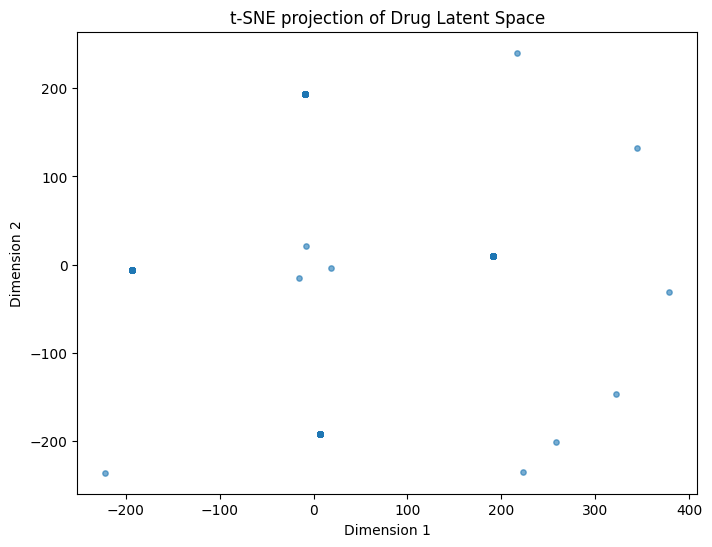

In [24]:
# ============================================================
# 📊 Visualize Latent Space (Optional)
# ============================================================
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt

# Reduce latent vectors to 2D for visualization
tsne = TSNE(n_components=2, perplexity=30, learning_rate=200, random_state=42)
latents_2d = tsne.fit_transform(latents[:2000])  # limit for speed

plt.figure(figsize=(8,6))
plt.scatter(latents_2d[:,0], latents_2d[:,1], alpha=0.6, s=15)
plt.title("t-SNE projection of Drug Latent Space")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()


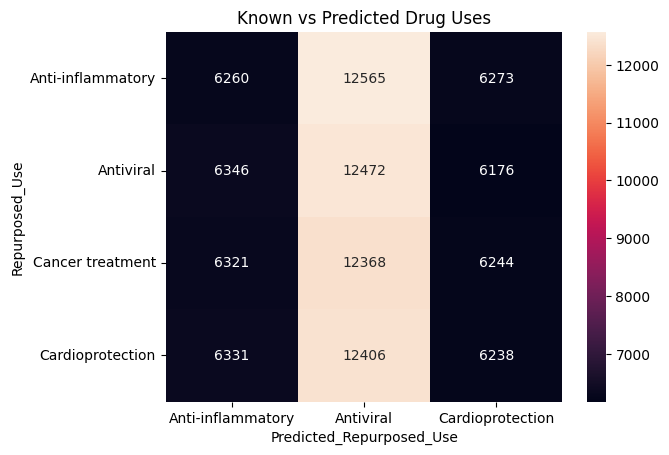

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.heatmap(pd.crosstab(df_valid['Repurposed_Use'], df_valid['Predicted_Repurposed_Use']), annot=True, fmt='d')
plt.title("Known vs Predicted Drug Uses")
plt.show()


ValueError: 'c' argument has 100000 elements, which is inconsistent with 'x' and 'y' with size 2000.

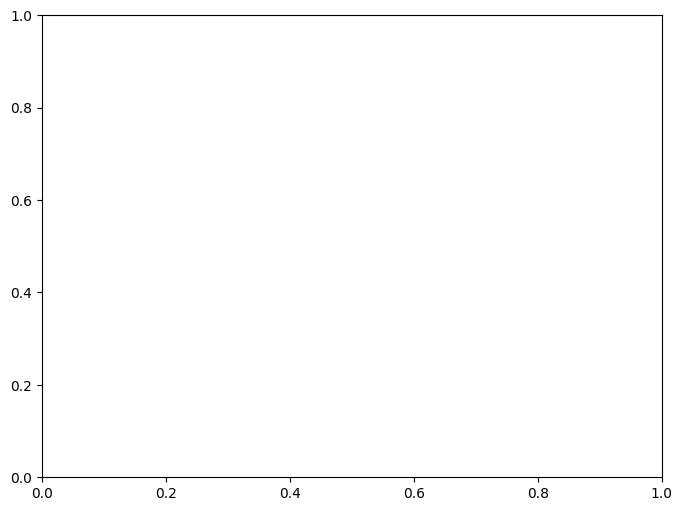

In [21]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
plt.scatter(latents_2d[:,0], latents_2d[:,1],
            c=pd.factorize(df_valid['Predicted_Repurposed_Use'])[0],
            cmap='tab10', alpha=0.7, s=20)
plt.title("t-SNE projection colored by Predicted Repurposed Use")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.show()
